<a href="https://colab.research.google.com/github/supritk21/ABBIG-Memory-Transfer-Experiments/blob/main/customer_chur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [242]:
import pandas as pd
import zipfile
import duckdb as db

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


import matplotlib.pyplot as plt
import seaborn as sns
### uzip zip file

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve


In [3]:
zip_path = '/content/customer_churn_dataset-testing-master.csv.zip'

extract_path = '/content/customer_churn_dataset-testing-master.csv'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print(f"Successfully extracted to {extract_path}")

Successfully extracted to /content/customer_churn_dataset-testing-master.csv


In [37]:
churn_data = pd.read_csv('/content/customer_churn_dataset-testing-master.csv/customer_churn_dataset-testing-master.csv')

In [10]:
churn_data.sample(4)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
33651,33652,50,Female,1,27,6,10,Standard,Annual,482,27,0
58227,58228,38,Male,48,3,6,16,Basic,Monthly,429,17,1
47228,47229,39,Male,34,30,5,23,Premium,Quarterly,711,26,1
15096,15097,28,Male,11,2,8,23,Basic,Annual,457,18,1


In [15]:
churn_data.shape

(64374, 12)

In [13]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [12]:
churn_data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [22]:
churn_data.isna().sum()

,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0
Last Interaction,0


In [38]:
churn_data[churn_data.isnull().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn


In [39]:
churn_data.drop(['CustomerID'], axis = 1, inplace = True)

In [40]:
churn_data.dropna(inplace = True)

In [41]:
churn_data.shape

(64374, 11)

In [42]:
churn_data.drop_duplicates(inplace = True)
## remove null  df.dropna(inplace = True)
## frop duplicates df.drop_duplicates(inplace = True)

In [33]:
# churn_data

churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                64374 non-null  int64 
 1   Gender             64374 non-null  object
 2   Tenure             64374 non-null  int64 
 3   Usage Frequency    64374 non-null  int64 
 4   Support Calls      64374 non-null  int64 
 5   Payment Delay      64374 non-null  int64 
 6   Subscription Type  64374 non-null  object
 7   Contract Length    64374 non-null  object
 8   Total Spend        64374 non-null  int64 
 9   Last Interaction   64374 non-null  int64 
 10  Churn              64374 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 5.4+ MB


In [34]:
churn_data.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [43]:
numeric_feat = [ 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn' ]
churn_data[numeric_feat] = churn_data[numeric_feat].astype('int')


#### eda start


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_20150/2416812701.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot( x = 'Churn', data = churn_data, palette=  'rocket')


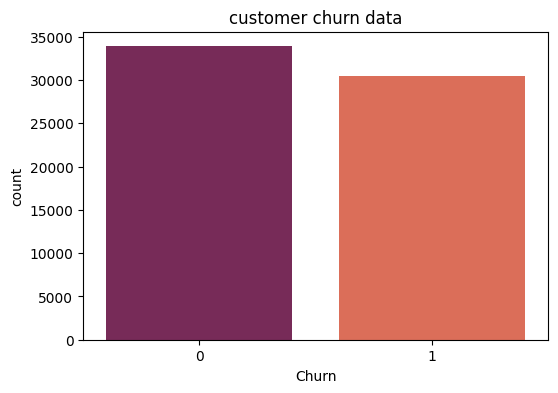

Churn
0    0.526315
1    0.473685
Name: proportion, dtype: float64


In [58]:
plt.figure( figsize = (6, 4))
sns.countplot( x = 'Churn', data = churn_data, palette=  'rocket')
plt.title("customer churn data")

plt.show()
# print(df['Churn'].value_counts(normalize=True) * 100)
print(churn_data['Churn'].value_counts(normalize = True) )

- the data set is relatively balanced

/tmp/ipykernel_20150/3885667612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Gender', y = 'Churn', data = gender_churn_rate, palette = 'coolwarm' )


(0.0, 1.0)

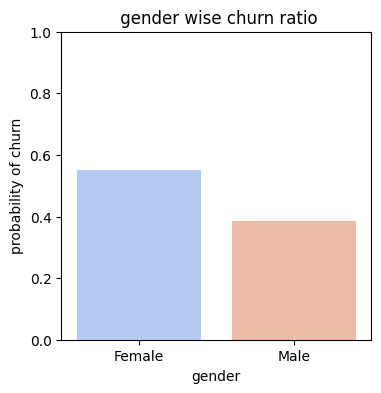

In [90]:
gender_churn_rate = churn_data.groupby('Gender')['Churn'].mean().reset_index()
plt.figure(figsize = (4,4))
sns.barplot(x = 'Gender', y = 'Churn', data = gender_churn_rate, palette = 'coolwarm' )

plt.title(' gender wise churn ratio')
plt.xlabel("gender")
plt.ylabel("probability of churn")
plt.ylim((0,1))
# gennder_churn_rate

- probability of female will churn is high

In [79]:
db.sql(""" SELECT Gender, Mean(Churn) AS churn FROM churn_data GROUP BY Gender """).df()

,Gender,churn
0,Female,0.550490
1,Male,0.385797


In [91]:
db.sql(""" SELECT "Subscription Type", Mean(Churn) AS churn FROM churn_data GROUP BY "Subscription Type" """).df()

,Subscription Type,churn
0,Basic,0.482775
1,Standard,0.473305
2,Premium,0.464964


Text(0, 0.5, 'probability density')

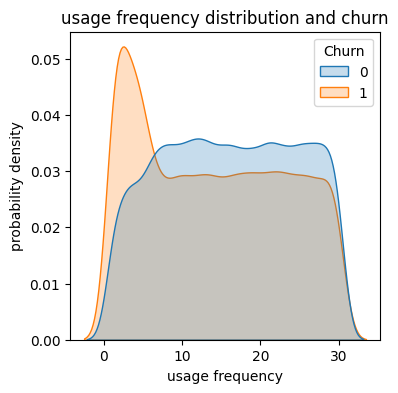

In [101]:
plt.figure( figsize = (4, 4 ))
sns.kdeplot( x = 'Usage Frequency', data = churn_data , hue = 'Churn' , common_norm = False, fill = True)
plt.title("usage frequency distribution and churn")
plt.xlabel("usage frequency")
plt.ylabel("probability density")

- when usage frequency is low high chance of churn
- when usage frequency is high low chance ofchurn

Text(0, 0.5, 'probability density')

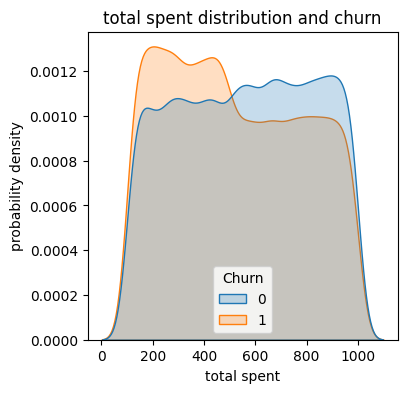

In [103]:
plt.figure( figsize = (4, 4 ))
sns.kdeplot( x = 'Total Spend', data = churn_data , hue = 'Churn' , common_norm = False, fill = True)
plt.title("total spent distribution and churn")
plt.xlabel("total spent")
plt.ylabel("probability density")

In [ ]:
'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction',

/tmp/ipykernel_20150/2944412735.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x='Age Group', y='Churn', data = churn_data, palette = 'viridis')


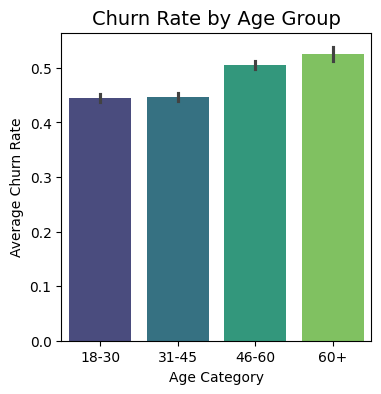

In [126]:
bins = [18, 31, 46, 61, 100]
labels = [ '18-30', '31-45', '46-60', '60+']
churn_data['Age Group'] = pd.cut(churn_data['Age'], bins=bins, labels = labels, right =False)

plt.figure( figsize=(4,4))
sns.barplot( x='Age Group', y='Churn', data = churn_data, palette = 'viridis')
plt.title('Churn Rate by Age Group', fontsize=14)
plt.xlabel('Age Category')
plt.ylabel('Average Churn Rate')
plt.show()


/tmp/ipykernel_20150/1301726968.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x = 'Subscription Type', y = 'Churn', data = churn_data, palette = 'magma' )


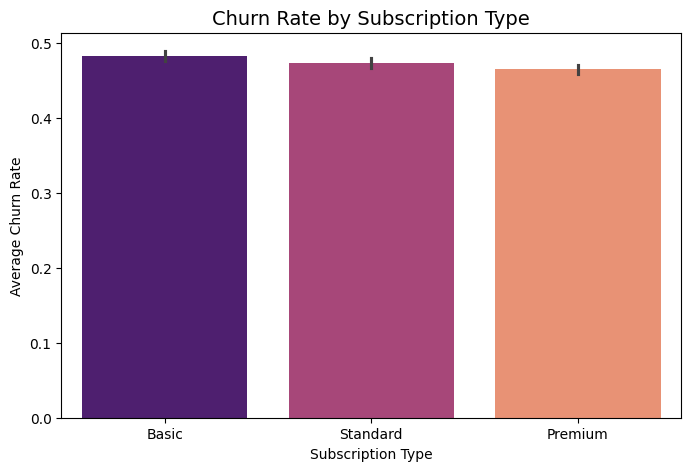

In [127]:
plt.figure(figsize=(8, 5))
sns.barplot( x = 'Subscription Type', y = 'Churn', data = churn_data, palette = 'magma' )

plt.title('Churn Rate by Subscription Type', fontsize=14)
plt.xlabel('Subscription Type')
plt.ylabel('Average Churn Rate')
plt.show()

- not depend on subscription type. churn rate is almost same for all subscription type

<Axes: xlabel='Churn', ylabel='Support Calls'>

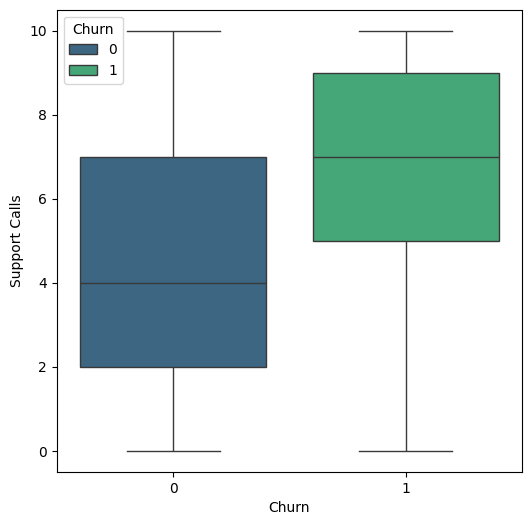

In [137]:
plt.figure( figsize = (6,6))
sns.boxplot(x = 'Churn', y = 'Support Calls', data = churn_data, hue = 'Churn', palette = 'viridis')

/tmp/ipykernel_20150/915547004.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Support Calls', y = 'Churn', data = churn_data, palette = 'magma'  )


<Axes: xlabel='Support Calls', ylabel='Churn'>

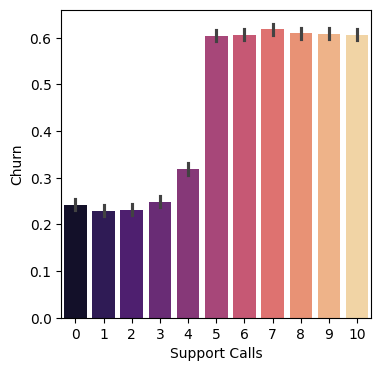

In [141]:
plt.figure(figsize = (4,4))
sns.barplot(x = 'Support Calls', y = 'Churn', data = churn_data, palette = 'magma'  )

- Observation:  churn rate increase as the number of support call increaseing
- analysis: median support calls by loyal customer is 4 where as by churn is 7. after 4 support  calls there is high chance customer will churn

/tmp/ipykernel_20150/620752315.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot( x ='Churn', y='Payment Delay', data = churn_data, palette='magma')


[]

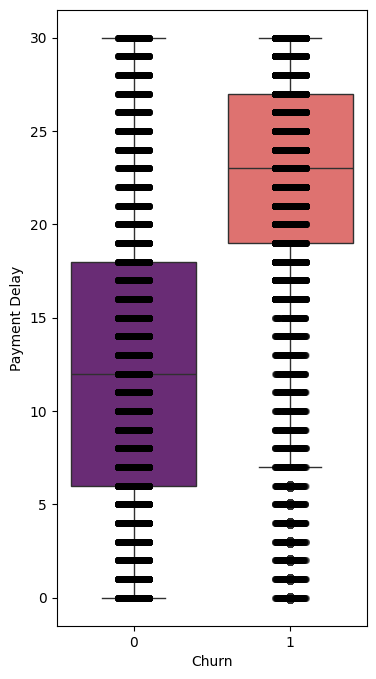

In [158]:
plt.figure(figsize = (4,8) )
sns.boxplot( x ='Churn', y='Payment Delay', data = churn_data, palette='magma')
sns.stripplot(x='Churn', y='Payment Delay', data=churn_data,
              color='black', alpha=0.3, jitter=True)

plt.plot()

/tmp/ipykernel_20150/3457323465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Payment Delay' , y = 'Churn', data = churn_data, palette='magma' )


<Axes: xlabel='Payment Delay', ylabel='Churn'>

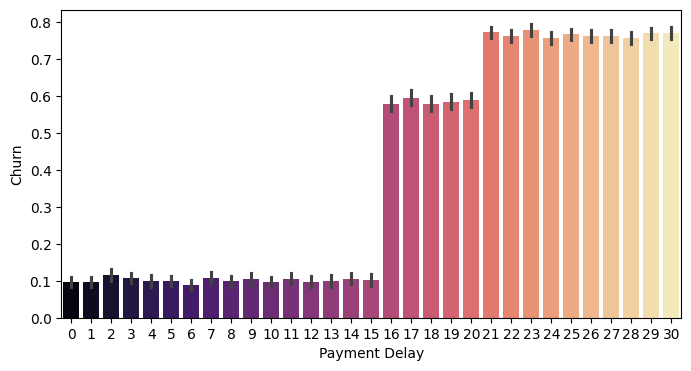

In [153]:
plt.figure(figsize = (8,4))
sns.barplot(x = 'Payment Delay' , y = 'Churn', data = churn_data, palette='magma' )

- observation : churn rate increasing as payment delayed
- analysis : with 15 days delay in payment there is 500% chances that the customer will churn
- mediam delay of loyal customer is 12 and churn customer is 23

/tmp/ipykernel_20150/3795628372.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Churn', y = 'Usage Frequency', data = churn_data, palette = 'magma')


[]

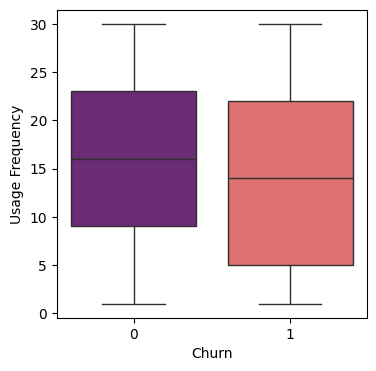

In [161]:
# churn_data['Usage Frequency'].unique()
plt.figure( figsize=(4,4))
sns.boxplot(x = 'Churn', y = 'Usage Frequency', data = churn_data, palette = 'magma')
plt.plot()

/tmp/ipykernel_20150/3225754246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Usage Frequency', y = 'Churn', data = churn_data, palette = 'magma')


[]

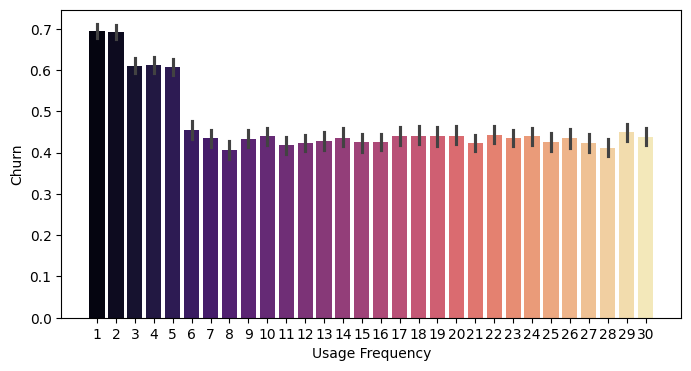

In [164]:
plt.figure( figsize=(8,4))
sns.barplot(x = 'Usage Frequency', y = 'Churn', data = churn_data, palette = 'magma')
plt.plot()

In [169]:
db.sql("""
SELECT CASE
          WHEN "Usage Frequency"<6 THEN 'usg_freq_less_6'
          ELSE 'usg_freq_grtr_6'
       END AS usage_freq, SUM(Churn)/COUNT(Churn)*100 AS chrn_ratio
FROM churn_data GROUP BY ALL
""").df()

,usage_freq,chrn_ratio
0,usg_freq_grtr_6,43.243243
1,usg_freq_less_6,64.488000


In [173]:
(64-43)/43*100

48.837209302325576

- more the usage frequency lower the churn is.
- analysis when usage frequency is < 6 then there is 50% more chance that the user will churn than customer with usage frequency >= 6

/tmp/ipykernel_20150/2418518349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Last Interaction',  data = churn_data , palette = 'magma')


<Axes: xlabel='Churn', ylabel='Last Interaction'>

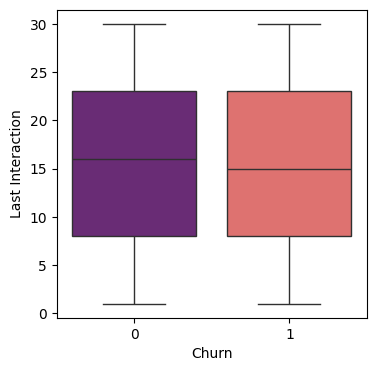

In [174]:
plt.figure(figsize = (4,4))
sns.boxplot(x='Churn', y='Last Interaction',  data = churn_data , palette = 'magma')

/tmp/ipykernel_20150/2845235672.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x='Last Interaction', y='Churn', data = churn_data, palette = 'magma')


<Axes: xlabel='Last Interaction', ylabel='Churn'>

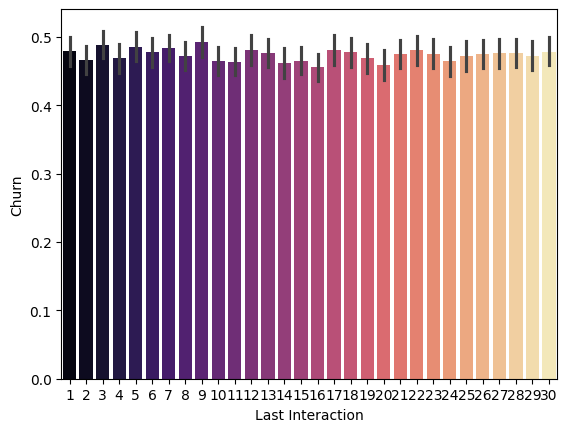

In [176]:
sns.barplot( x='Last Interaction', y='Churn', data = churn_data, palette = 'magma')

<Axes: xlabel='Last Interaction', ylabel='Density'>

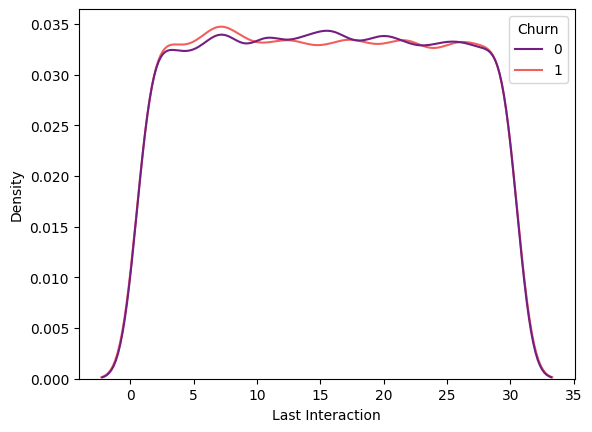

In [181]:
sns.kdeplot( x = 'Last Interaction', hue = 'Churn', data = churn_data, common_norm = False, palette = 'magma')

In [193]:
spend_bins = [ i for i in range(100, 1001, 100)]
spent_labels = [f"{i}-{i+99}" for i in range(100, 1000, 100)]

churn_data['spend-grp'] = pd.cut(churn_data['Total Spend'], bins = spend_bins, labels = spent_labels)


/tmp/ipykernel_20150/659042512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x = 'spend-grp', y = 'Churn', data = churn_data, palette = 'magma' )


(0.0, 1.0)

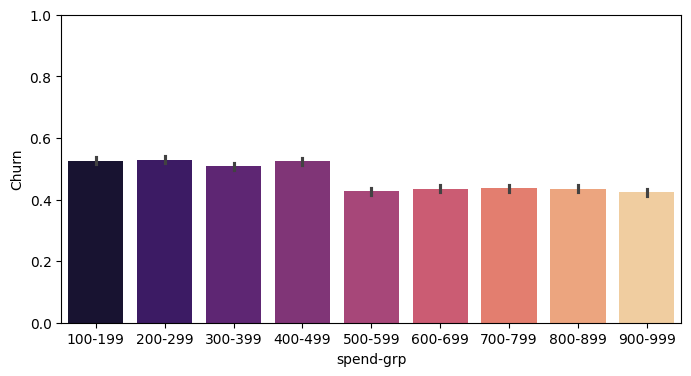

In [199]:
plt.figure(figsize = (8, 4))
sns.barplot( x = 'spend-grp', y = 'Churn', data = churn_data, palette = 'magma' )
plt.ylim(0,1)

<Axes: >

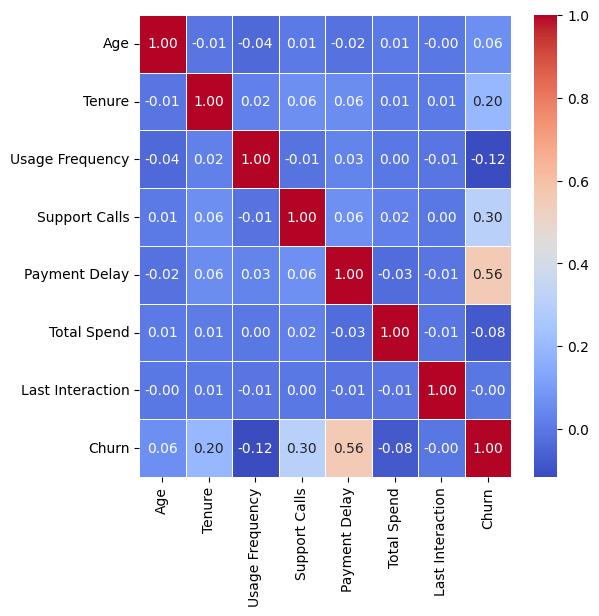

In [206]:
numeric_df = churn_data.select_dtypes( include = [ 'float64', 'int64' ] )
corr_matx = numeric_df.corr()

plt.figure(figsize = (6,6))
sns.heatmap( corr_matx, annot = True, fmt = "0.2f", cmap = 'coolwarm', linewidths=0.5 )

In [214]:
model_data.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [212]:
model_data = churn_data.drop(columns = ['Age Group', 'spend-grp' ], errors='ignore')

In [216]:
model_data['Gender'] = model_data['Gender'].map({ 'Male':1, 'Female':0 })

In [219]:
model_data = pd.get_dummies(model_data, columns=['Subscription Type', 'Contract Length'], drop_first= True, dtype = int )

In [222]:
X = model_data.drop(columns = ['Churn'], errors = 'ignore')
y = model_data['Churn']

In [225]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [237]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [251]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

results = []

In [253]:
for name , model in models.items():
  if name in ( 'Logistic Regression', 'KNN' ):
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    y_prob = model.predict_proba(x_test_scaled)
  else:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)

  acc = accuracy_score(y_test, y_pred)
  f1s = f1_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  pre = precision_score(y_test, y_pred)
  roc = roc_auc_score(y_test, y_pred)

  results.append([name, acc, f1s, rec, pre, roc])

In [254]:
result_df = pd.DataFrame( results, columns = ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]).sort_values(by='F1', ascending = False)

result_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
5,XGBoost,0.999767,0.999753,0.999671,0.999836,0.999762
4,Random Forest,0.997981,0.997860,0.996547,0.999176,0.997906
3,KNN,0.909126,0.906743,0.935219,0.879950,0.910492
1,KNN,0.909126,0.906743,0.935219,0.879950,0.910492
0,Logistic Regression,0.832000,0.823960,0.832292,0.815794,0.832015
2,Logistic Regression,0.832000,0.823960,0.832292,0.815794,0.832015


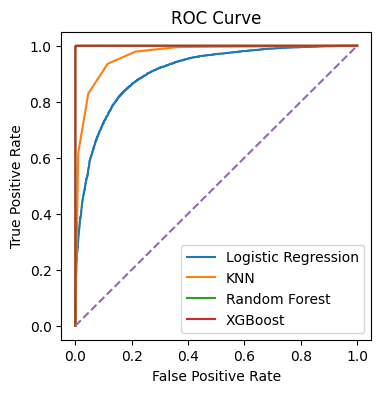

In [257]:
plt.figure( figsize = (4,4))

for name, model in models.items():
  if name in ( 'Logistic Regression', 'KNN' ):
    y_prob = model.predict_proba(x_test_scaled)[:,1]
  else:
    y_prob = model.predict_proba(x_test)[:,1]

  fpr, tpr, _ = roc_curve(y_test, y_prob)
  plt.plot(fpr, tpr, label = name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



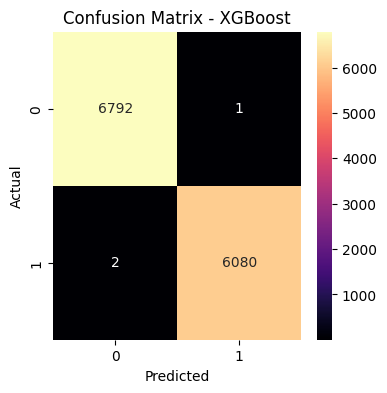

In [291]:
best_model_name = "".join(result_df['Model'][:1].to_list())
best_model = models[best_model_name]

if name in ( 'Logistic Regression', 'KNN' ):
  y_pred = best_model.predict(x_test_scaled)
else:
  y_pred = best_model.predict(x_test)

cf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))

sns.heatmap(cf, annot = True, fmt = 'd', cmap = 'magma')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [285]:
cf

array([[6792,    1],
       [   2, 6080]])

/tmp/ipykernel_20150/3429311819.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


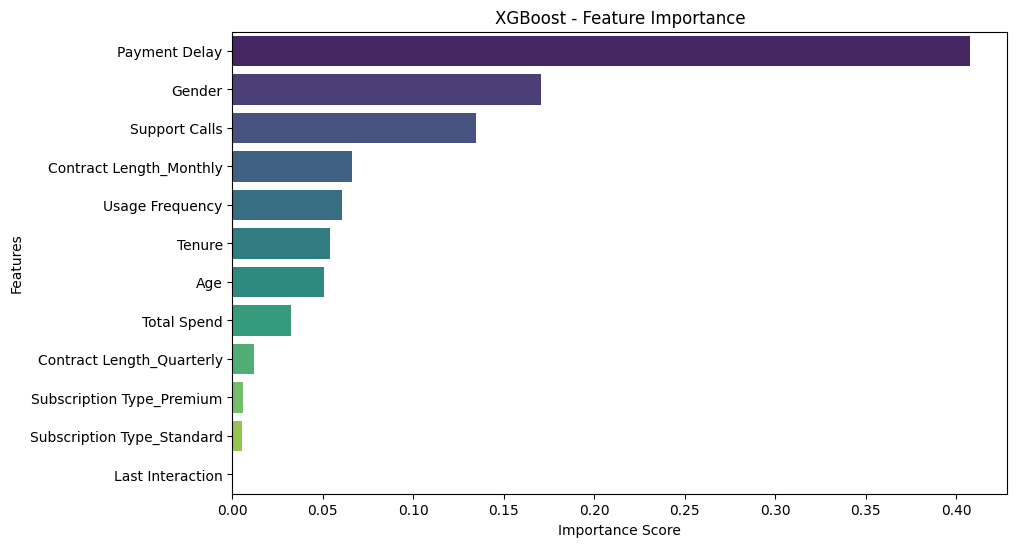

In [292]:
importances = models["XGBoost"].feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('XGBoost - Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [194]:
churn_data

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Age Group,spend-grp
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1,18-30,500-599
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0,31-45,500-599
2,47,Male,27,10,2,29,Premium,Annual,757,21,0,46-60,700-799
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0,31-45,200-299
4,53,Female,58,24,9,2,Standard,Annual,533,18,0,46-60,500-599
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64369,45,Female,33,12,6,21,Basic,Quarterly,947,14,1,31-45,900-999
64370,37,Male,6,1,5,22,Standard,Annual,923,9,1,31-45,900-999
64371,25,Male,39,14,8,30,Premium,Monthly,327,20,1,18-30,300-399
64372,50,Female,18,19,7,22,Standard,Monthly,540,13,1,46-60,500-599
